In [1]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import sys
module_path = os.path.abspath(os.path.join('../../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
from data_science_utilities.models.xgb.hyperparameter_search.random_search import OptimalXGBHyperparameterSearch

In [2]:
RANDOM_SEED = 32
# RFE on the dakota-free data recommends 54 features (get_best_num_features(.005)); see rfe.ipynb
BEST_NUM_FEATS = 54
TARGET = 'target_win'

RANDOM_XGB_PARAMS = {
    # How fast the model learns. The smaller, the more likely to get stuck in local minima, but the larger, the more likely to overshoot the global minima
    'learning_rate': [.03, .05, .1, .15, .2],
    # How deep the tree can be. The deeper, the more likely to overfit and more complex
    'max_depth': [2, 3],
    # The fraction of samples to be used for fitting the individual base learners. 
    # Values lower than 1 make the model more robust by preventing overfitting
    'subsample': [.5, .7, .9],
    # The minimum number of samples required to be at a leaf node. The larger, the more conservative
    'min_child_weight': [10, 20, 50, 100],
    # Minimum loss reduction required to make a split on a leaf node of the tree. Attempts to only split when it makes a significant improvement
    'gamma': [.5, 1, 5, 10, 100],
    # The number of trees to be used in the model. The more, the more likely to overfit
    'n_estimators': [10, 20,30, 40, 50],
    # The number of iterations the model can't improve before stopping
    'early_stopping_rounds': [10, 20, 50],
    # The way the model calculates the importance of each feature. Total gain is the sum of the gain of each feature used in the model
    'importance_type': ['total_gain'],
    # The evaluation metric to be used. AUC measures how well the model is able to distinguish between classes (win or loss)
    'eval_metric': ['auc']
}

RANDOM_SEARCH_PARAMS = dict(
    n_iter=100,
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_SEED,
    scoring='roc_auc',
)

BEST_FEATS_FROM_RFE = list(pd.read_csv(
    '../../../../../data/predict_games/model_features_in/rfe_features_kfolds.csv',
    index_col=0
).loc[BEST_NUM_FEATS, :].dropna().values)

MODEL_INPUTS_DF = pd.read_parquet(
    '../../../../../data/predict_games/input_data/schedule_and_weekly.parquet'
)

MODEL_INPUTS_DF = MODEL_INPUTS_DF.sample(
    frac=1, random_state=RANDOM_SEED
).reset_index(drop=True)

np.random.seed(RANDOM_SEED)

In [3]:
# Two-season holdout: train on everything before 2022, use 2022-2023 as the early-stopping
# test slice, and hold out 2024+2025 (the original 3-way split shifted one year forward).
train_df = MODEL_INPUTS_DF[(MODEL_INPUTS_DF['season'] < 2022)]
test_df = MODEL_INPUTS_DF[
    (MODEL_INPUTS_DF['season'] >= 2022) & (MODEL_INPUTS_DF['season'] < 2024)
]
holdout_df = MODEL_INPUTS_DF[MODEL_INPUTS_DF['season'] >= 2024].copy()
X_train = train_df[BEST_FEATS_FROM_RFE]
y_train = train_df[TARGET]
X_test = test_df[BEST_FEATS_FROM_RFE]
y_test = test_df[TARGET]
X_holdout = holdout_df[BEST_FEATS_FROM_RFE]
y_holdout = holdout_df[TARGET]

In [4]:
rand_hyperparam_search = OptimalXGBHyperparameterSearch(
    X_train, y_train, X_test, y_test
)

In [5]:
rand_search = rand_hyperparam_search.search(
    RANDOM_XGB_PARAMS, **RANDOM_SEARCH_PARAMS
)

[0]	validation_0-auc:0.62865	validation_1-auc:0.60382
[1]	validation_0-auc:0.65969	validation_1-auc:0.62192
[2]	validation_0-auc:0.67155	validation_1-auc:0.62575
[3]	validation_0-auc:0.67752	validation_1-auc:0.63065
[4]	validation_0-auc:0.68264	validation_1-auc:0.63483
[5]	validation_0-auc:0.68529	validation_1-auc:0.63792
[0]	validation_0-auc:0.62831	validation_1-auc:0.59150
[6]	validation_0-auc:0.68748	validation_1-auc:0.63742
[7]	validation_0-auc:0.69076	validation_1-auc:0.63912
[1]	validation_0-auc:0.65716	validation_1-auc:0.61238
[8]	validation_0-auc:0.69291	validation_1-auc:0.64315
[2]	validation_0-auc:0.67141	validation_1-auc:0.61790
[9]	validation_0-auc:0.69605	validation_1-auc:0.64405
[3]	validation_0-auc:0.67902	validation_1-auc:0.63159
[0]	validation_0-auc:0.61860	validation_1-auc:0.61223
[10]	validation_0-auc:0.69685	validation_1-auc:0.64736
[4]	validation_0-auc:0.68587	validation_1-auc:0.63628
[1]	validation_0-auc:0.63392	validation_1-auc:0.62269
[0]	validation_0-auc:0.6380

[39]	validation_0-auc:0.69125	validation_1-auc:0.64902
[22]	validation_0-auc:0.71678	validation_1-auc:0.64753
[22]	validation_0-auc:0.68308	validation_1-auc:0.64438
[28]	validation_0-auc:0.71986	validation_1-auc:0.64666
[18]	validation_0-auc:0.71545	validation_1-auc:0.65428
[36]	validation_0-auc:0.70934	validation_1-auc:0.65628
[22]	validation_0-auc:0.68268	validation_1-auc:0.65442
[43]	validation_0-auc:0.69196	validation_1-auc:0.65168
[22]	validation_0-auc:0.71330	validation_1-auc:0.64419
[40]	validation_0-auc:0.69123	validation_1-auc:0.64863
[23]	validation_0-auc:0.71740	validation_1-auc:0.64770
[29]	validation_0-auc:0.72022	validation_1-auc:0.64665
[19]	validation_0-auc:0.71622	validation_1-auc:0.65468
[23]	validation_0-auc:0.68492	validation_1-auc:0.64558
[23]	validation_0-auc:0.68202	validation_1-auc:0.65397
[41]	validation_0-auc:0.69144	validation_1-auc:0.64859
[44]	validation_0-auc:0.69241	validation_1-auc:0.65236
[23]	validation_0-auc:0.71394	validation_1-auc:0.64461
[25]	valid

[25]	validation_0-auc:0.70759	validation_1-auc:0.65314
[16]	validation_0-auc:0.70260	validation_1-auc:0.65242
[15]	validation_0-auc:0.68354	validation_1-auc:0.64792
[12]	validation_0-auc:0.68288	validation_1-auc:0.64968
[3]	validation_0-auc:0.65667	validation_1-auc:0.63550
[12]	validation_0-auc:0.68248	validation_1-auc:0.65524
[24]	validation_0-auc:0.70793	validation_1-auc:0.65018
[7]	validation_0-auc:0.66594	validation_1-auc:0.63646
[23]	validation_0-auc:0.70684	validation_1-auc:0.64723
[28]	validation_0-auc:0.70910	validation_1-auc:0.65441
[17]	validation_0-auc:0.70359	validation_1-auc:0.65248
[26]	validation_0-auc:0.70788	validation_1-auc:0.65333
[16]	validation_0-auc:0.68486	validation_1-auc:0.64911
[4]	validation_0-auc:0.66519	validation_1-auc:0.64092
[13]	validation_0-auc:0.68236	validation_1-auc:0.65447
[18]	validation_0-auc:0.70458	validation_1-auc:0.65299
[27]	validation_0-auc:0.70812	validation_1-auc:0.65413
[8]	validation_0-auc:0.67115	validation_1-auc:0.63783
[25]	validatio

[15]	validation_0-auc:0.69278	validation_1-auc:0.65121
[16]	validation_0-auc:0.69322	validation_1-auc:0.65500
[15]	validation_0-auc:0.69462	validation_1-auc:0.64870
[18]	validation_0-auc:0.69555	validation_1-auc:0.65388
[9]	validation_0-auc:0.64867	validation_1-auc:0.63798
[12]	validation_0-auc:0.63901	validation_1-auc:0.62546
[16]	validation_0-auc:0.69457	validation_1-auc:0.65086
[17]	validation_0-auc:0.69479	validation_1-auc:0.65582
[6]	validation_0-auc:0.67656	validation_1-auc:0.64157
[19]	validation_0-auc:0.69649	validation_1-auc:0.65353
[1]	validation_0-auc:0.60854	validation_1-auc:0.59562
[10]	validation_0-auc:0.64867	validation_1-auc:0.63798
[13]	validation_0-auc:0.63901	validation_1-auc:0.62546
[16]	validation_0-auc:0.69653	validation_1-auc:0.65028
[18]	validation_0-auc:0.69583	validation_1-auc:0.65606
[17]	validation_0-auc:0.69514	validation_1-auc:0.65254
[11]	validation_0-auc:0.64867	validation_1-auc:0.63798
[0]	validation_0-auc:0.57271	validation_1-auc:0.56906
[18]	validatio

[34]	validation_0-auc:0.62936	validation_1-auc:0.61789
[1]	validation_0-auc:0.61279	validation_1-auc:0.59568
[24]	validation_0-auc:0.69369	validation_1-auc:0.64591
[28]	validation_0-auc:0.69393	validation_1-auc:0.65702
[25]	validation_0-auc:0.69197	validation_1-auc:0.65310
[28]	validation_0-auc:0.64148	validation_1-auc:0.62638
[35]	validation_0-auc:0.62936	validation_1-auc:0.61789
[2]	validation_0-auc:0.63639	validation_1-auc:0.61982
[29]	validation_0-auc:0.69433	validation_1-auc:0.65699
[25]	validation_0-auc:0.69394	validation_1-auc:0.64573
[26]	validation_0-auc:0.69282	validation_1-auc:0.65212
[32]	validation_0-auc:0.63483	validation_1-auc:0.62030
[26]	validation_0-auc:0.63955	validation_1-auc:0.62998
[3]	validation_0-auc:0.63457	validation_1-auc:0.62092
[30]	validation_0-auc:0.69478	validation_1-auc:0.65738
[26]	validation_0-auc:0.69476	validation_1-auc:0.64610
[36]	validation_0-auc:0.62936	validation_1-auc:0.61789
[33]	validation_0-auc:0.63483	validation_1-auc:0.62030
[29]	validati

...

[36]	validation_0-auc:0.70438	validation_1-auc:0.64534


[37]	validation_0-auc:0.70468	validation_1-auc:0.64534


[38]	validation_0-auc:0.70499	validation_1-auc:0.64510


[39]	validation_0-auc:0.70518	validation_1-auc:0.64543




Best parameters found:  {'subsample': 0.7, 'n_estimators': 40, 'min_child_weight': 20, 'max_depth': 2, 'learning_rate': 0.15, 'importance_type': 'total_gain', 'gamma': 10, 'eval_metric': 'auc', 'early_stopping_rounds': 50}


Best score found:  0.6808668461403065


Best Selected Features:  ['is_home_target', 'target_def_cumulative_avg_points_allowed_rank', 'opp_def_cumulative_avg_points_allowed_rank', 'off_opp_passing_epa_cumulative_average_rank', 'target_off_cumulative_avg_score_rank', 'opp_off_cumulative_avg_score_rank', 'off_target_passing_epa_cumulative_average_rank', 'off_target_pacr', 'def_opp_rushing_yards_cumulative_average_rank', 'off_target_interceptions_cumulative_average_rank', 'def_target_carries_cumulative_average_rank', 'def_target_rushing_fumbles_lost_cumulative_average_rank', 'def_opp_attempts', 'def_target_attempts', 'def_target_rushing_yards_cumulative_average_rank', 'def_opp_rushing_tds_cumulative_average_rank', 'def_opp_racr', 'def_target_rushing_tds_cumulative_av

In [6]:
# view all the scores from the search
rand_search.cv_results_

{'mean_fit_time': array([0.22119017, 0.27664614, 0.24341998, 0.25535936, 0.28620257,
        0.1148138 , 0.16413875, 0.11712079, 0.23823323, 0.18811255,
        0.09616423, 0.09207816, 0.19971533, 0.17870641, 0.24627757,
        0.13304744, 0.12694407, 0.14885039, 0.12156706, 0.09771891,
        0.09042945, 0.14203796, 0.16257267, 0.18416934, 0.18581924,
        0.28934474, 0.14863806, 0.14251804, 0.19964027, 0.1853406 ,
        0.17447057, 0.26264915, 0.13385119, 0.21315207, 0.09649501,
        0.08968205, 0.13311687, 0.1684154 , 0.09708109, 0.12630591,
        0.2219296 , 0.25447326, 0.11105781, 0.12239938, 0.17801161,
        0.09332027, 0.08878899, 0.13129339, 0.156213  , 0.19344826,
        0.16147575, 0.09339256, 0.2392818 , 0.09552016, 0.20019641,
        0.14094472, 0.25817666, 0.09553432, 0.21118841, 0.10439577,
        0.16807251, 0.17159858, 0.0910399 , 0.09131198, 0.13050275,
        0.16487918, 0.11071606, 0.13377333, 0.16738424, 0.24587026,
        0.16041694, 0.12885089,

<Axes: >

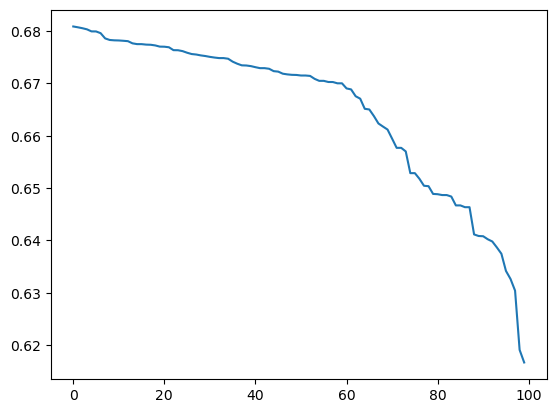

In [7]:
# Graph the search results. Make the index the rank of the score
# another column for the mean test score
rand_search_results = pd.DataFrame(rand_search.cv_results_)
rand_search_results['rank_test_score'] = rand_search_results['rank_test_score']
rand_search_results['mean_test_score'] = rand_search_results['mean_test_score']
rand_search_results = rand_search_results.sort_values(by='rank_test_score', ascending=True)
rand_search_results = rand_search_results.reset_index(drop=True)
rand_search_results['mean_test_score'].plot()

In [8]:
# What are the grid search params for the top 5 scores?
rand_search_results.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,param_importance_type,...,param_early_stopping_rounds,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.197043,0.009909,0.002641,0.000026,0.7,40,20,2,0.15,total_gain,...,50,"{'subsample': 0.7, 'n_estimators': 40, 'min_ch...",0.681453,0.679369,0.673419,0.677166,0.692927,0.680867,0.006591,1
1,0.224109,0.026403,0.003686,0.000802,0.7,40,100,3,0.2,total_gain,...,20,"{'subsample': 0.7, 'n_estimators': 40, 'min_ch...",0.673754,0.683210,0.670047,0.681132,0.695418,0.680712,0.008773,2
2,0.255359,0.014084,0.003798,0.000739,0.7,40,20,3,0.1,total_gain,...,50,"{'subsample': 0.7, 'n_estimators': 40, 'min_ch...",0.678823,0.675408,0.669596,0.679217,0.699635,0.680536,0.010153,3
3,0.262649,0.010525,0.004490,0.001473,0.7,50,20,3,0.1,total_gain,...,50,"{'subsample': 0.7, 'n_estimators': 50, 'min_ch...",0.678823,0.675408,0.669596,0.678150,0.699635,0.680322,0.010190,4
4,0.286203,0.019211,0.004152,0.001820,0.7,50,100,2,0.1,total_gain,...,50,"{'subsample': 0.7, 'n_estimators': 50, 'min_ch...",0.678834,0.680991,0.668325,0.675235,0.696264,0.679930,0.009229,5


In [9]:
# save the json of the best model
best_model = rand_search.best_estimator_
best_model.save_model(
    os.path.join(module_path, 'models', 'best_random_xgb_model.json')
)

In [10]:
# What is the score on the holdout set?
best_model.score(X_holdout, y_holdout)

0.6470588235294118

In [11]:
holdout_df.loc[:, 'preds'] = best_model.predict_proba(X_holdout)[:, 1]

In [12]:
# Show the predictions for the holdout set
results_df = holdout_df[
    ['game_id', 'week', 'target_team', 'opp_team', 'target_win', 'preds']
].copy()
results_df.sort_values(by='game_id', inplace=True)
results_df.reset_index(drop=True, inplace=True)
results_df

,game_id,week,target_team,opp_team,target_win,preds
0,2024_01_ARI_BUF,1,ARI,BUF,0,0.203470
1,2024_01_ARI_BUF,1,BUF,ARI,1,0.747668
2,2024_01_BAL_KC,1,KC,BAL,1,0.616716
3,2024_01_BAL_KC,1,BAL,KC,0,0.402525
4,2024_01_CAR_NO,1,CAR,NO,0,0.224953
...,...,...,...,...,...,...
1083,2025_18_SEA_SF,18,SF,SEA,0,0.533563
1084,2025_18_TEN_JAX,18,JAX,TEN,1,0.740934
1085,2025_18_TEN_JAX,18,TEN,JAX,0,0.231501
1086,2025_18_WAS_PHI,18,PHI,WAS,0,0.770922


week
1     0.919922
2     0.688477
3     0.540039
4     0.598633
5     0.450255
6     0.731272
7     0.814444
8     0.772889
9     0.713436
10    0.665816
11    0.780024
12    0.781893
13    0.746094
14    0.733882
15    0.788086
16    0.625977
17    0.610352
18    0.640625
dtype: float64

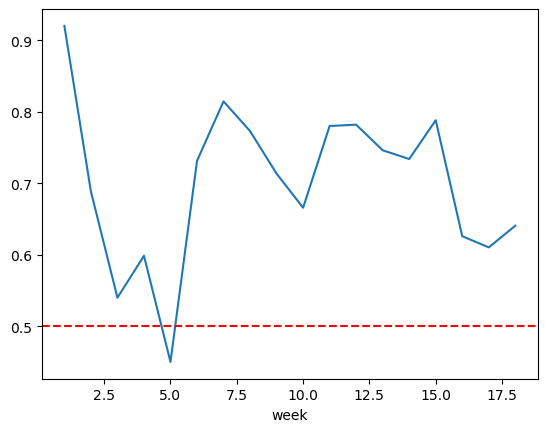

In [13]:
# get the AUROC score by week
weekly_scores = holdout_df.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores

In [14]:
# for each game_id, only keep the higher prediction
higher_preds = holdout_df.groupby('game_id').apply(
    lambda x: x.loc[x['preds'].idxmax(), :],
    include_groups=False
)
higher_preds.reset_index(drop=True, inplace=True)

week
1     0.762963
2     0.623482
3     0.505882
4     0.718750
5     0.510417
6     0.638889
7     0.693182
8     0.666667
9     0.631579
10    0.387500
11    0.803030
12    0.523810
13    0.636364
14    0.485714
15    0.514286
16    0.803922
17    0.592157
18    0.630952
dtype: float64

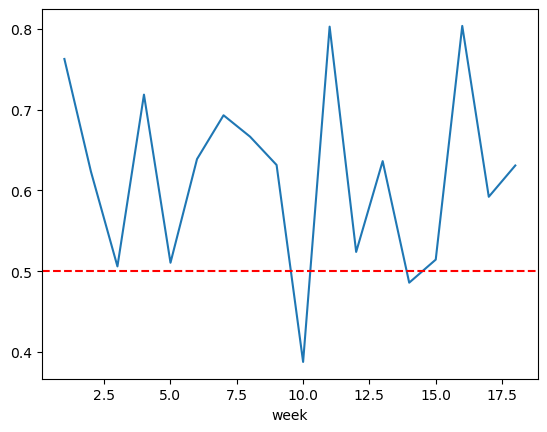

In [15]:
# get the AUROC score by week
weekly_scores = higher_preds.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores

## How good are the model's *confident* predictions?

AUROC only measures **ranking** (can the model sort winners above losers?). It says
nothing about whether a 0.80 prediction is actually right ~80% of the time. The cells
below answer "when the model has a strong prediction, how well does it predict?" using:

1. **Brier score & log loss** — residual-based metrics that penalize overconfidence.
2. **Confidence-bucketed accuracy** — the direct answer: how often the favored team wins,
   grouped by how sure the model was.
3. **Reliability diagram** — visual calibration check (predicted prob vs observed win rate).

Note: `holdout_df` has two rows per `game_id` (one per team). Brier/log loss are computed
on all rows consistently; the bucketed-accuracy table uses the one-row-per-game `higher_preds`
frame so each game is counted once.

In [16]:
# Residual-based metrics. Unlike AUROC, these penalize confident-and-wrong predictions.
from sklearn.metrics import brier_score_loss, log_loss

brier = brier_score_loss(holdout_df['target_win'], holdout_df['preds'])
ll = log_loss(holdout_df['target_win'], holdout_df['preds'])
print(f"Brier score: {brier:.4f}  (lower is better; 0.25 = coin flip)")
print(f"Log loss:    {ll:.4f}  (lower is better; punishes confident-and-wrong hardest)")

Brier score: 0.2218  (lower is better; 0.25 = coin flip)
Log loss:    0.6341  (lower is better; punishes confident-and-wrong hardest)


In [17]:
# Confidence-bucketed accuracy: the direct answer to "when the model is confident, is it right?"
# On higher_preds, `preds` is the model's confidence in its pick (0.5-1.0) and
# target_win == 1 means the favored team actually won.
higher_preds['confidence'] = higher_preds['preds']
higher_preds['bucket'] = pd.cut(
    higher_preds['confidence'], bins=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
)

confidence_summary = higher_preds.groupby('bucket', observed=True).agg(
    n_games=('target_win', 'size'),
    pick_accuracy=('target_win', 'mean'),   # how often the favored team won
    avg_confidence=('confidence', 'mean'),  # what the model claimed
)
# Positive gap = overconfident (claimed more than it delivered)
confidence_summary['calibration_gap'] = (
    confidence_summary['avg_confidence'] - confidence_summary['pick_accuracy']
)
confidence_summary

,n_games,pick_accuracy,avg_confidence,calibration_gap
bucket,,,,
"(0.5, 0.6]",253,0.569170,0.547293,-0.021877
"(0.6, 0.7]",186,0.672043,0.646190,-0.025853
"(0.7, 0.8]",83,0.819277,0.738285,-0.080992
"(0.8, 0.9]",2,1.000000,0.828877,-0.171123


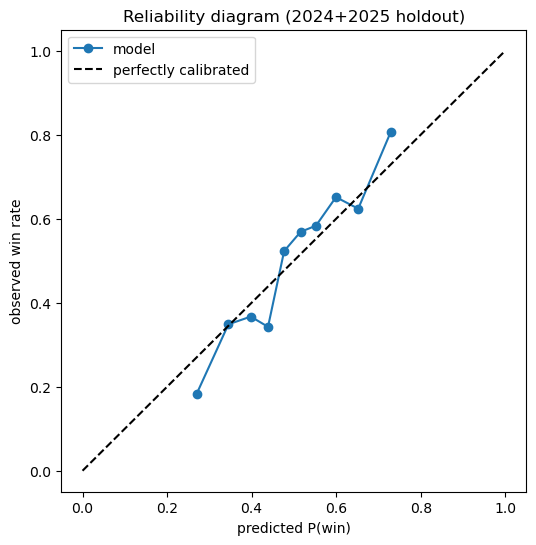

In [18]:
# Reliability diagram: are the probabilities trustworthy?
# Points on the diagonal = perfectly calibrated. Below the diagonal on the right
# side = the model is overconfident when bullish.
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    holdout_df['target_win'], holdout_df['preds'], n_bins=10, strategy='quantile'
)
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='model')
plt.plot([0, 1], [0, 1], 'k--', label='perfectly calibrated')
plt.xlabel('predicted P(win)')
plt.ylabel('observed win rate')
plt.title('Reliability diagram (2024+2025 holdout)')
plt.legend()
plt.show()

## Does a wider home-vs-away gap mean better predictions?

Each game has two predictions: `P(home wins)` from the home-perspective row and
`P(away wins)` from the away-perspective row. The **gap** between them is a stronger
confidence signal than `max(pred)` alone — it uses *both* perspectives. A wide gap
means the two views agree strongly on a winner; a narrow gap means the model is torn.

Hypothesis: when the gap is wide, accuracy should be higher. We pivot the two rows onto
one row per game (via `is_home_target`), define the model's pick as whichever side has
the higher probability, and bucket accuracy by gap width (quintiles, so every bin is
populated).

In [19]:
# Pivot the two perspectives of each game onto one row (is_home_target: 1 = home, 0 = away)
game_view = holdout_df.pivot_table(
    index='game_id', columns='is_home_target', values=['preds', 'target_win'], aggfunc='first'
).dropna()

games = pd.DataFrame({
    'home_pred': game_view[('preds', 1)],
    'away_pred': game_view[('preds', 0)],
    'home_won':  game_view[('target_win', 1)].astype(int),
})
games['gap']           = games['home_pred'] - games['away_pred']   # >0 leans home, <0 leans away
games['abs_gap']       = games['gap'].abs()                        # strength of the lean
games['pred_home_win'] = games['home_pred'] > games['away_pred']
games['correct']       = games['pred_home_win'] == (games['home_won'] == 1)

# Bucket by gap width (quintiles) and measure accuracy in each
games['gap_quintile'] = pd.qcut(games['abs_gap'], 5)
gap_summary = games.groupby('gap_quintile', observed=True).agg(
    n_games=('correct', 'size'),
    mean_abs_gap=('abs_gap', 'mean'),
    accuracy=('correct', 'mean'),
)
print(f"Overall correlation(abs_gap, correct): {games['abs_gap'].corr(games['correct'].astype(int)):.3f}")
gap_summary

Overall correlation(abs_gap, correct): 0.208


,n_games,mean_abs_gap,accuracy
gap_quintile,,,
"(0.00081, 0.0739]",109,0.040824,0.458716
"(0.0739, 0.151]",109,0.110754,0.651376
"(0.151, 0.252]",108,0.199856,0.648148
"(0.252, 0.364]",109,0.306662,0.642202
"(0.364, 0.655]",109,0.455456,0.807339


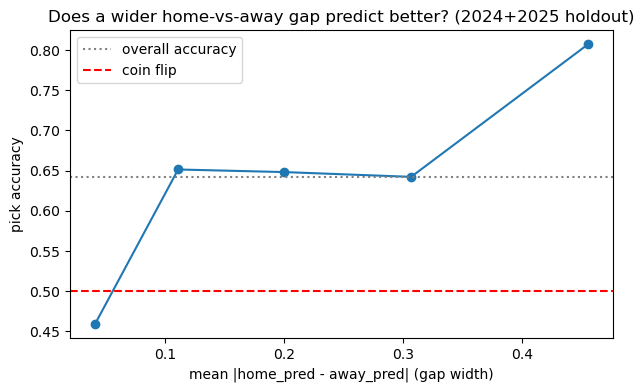

In [20]:
# Visualize the hypothesis: accuracy should rise as the home-vs-away gap widens
plt.figure(figsize=(7, 4))
plt.plot(gap_summary['mean_abs_gap'], gap_summary['accuracy'], marker='o')
plt.axhline(y=games['correct'].mean(), color='gray', linestyle=':', label='overall accuracy')
plt.axhline(y=0.5, color='r', linestyle='--', label='coin flip')
plt.xlabel('mean |home_pred - away_pred| (gap width)')
plt.ylabel('pick accuracy')
plt.title('Does a wider home-vs-away gap predict better? (2024+2025 holdout)')
plt.legend()
plt.show()